# Breast Cancer Veri Seti ile Başlangıç

Bu notebook, ödevin ilk aşaması için başlangıç seviyesinde hazırlandı. Amacımız veri setini yüklemek, tabloyu
görmek, kolonları incelemek ve temel yapısını anlamak.


## 1. Veri Setinin Yüklenmesi, `X` ve `y` Oluşturma

Bu adımda scikit-learn içindeki **Breast Cancer** veri setini yüklüyorum. Ardından, modeli kurarken kullanacağımız 
özellik matrisi `X` ile hedef değişken `y`’yi oluşturup pandas yapısına (DataFrame/Series) dönüştürüyorum. 
Amaç; veri setinin biçimini, boyutunu ve ilk gözlemlerini netleştirmektir.


### 1.1 Veri Setini Yükleme

Önce gerekli kütüphaneleri içe aktarıyorum ve veri setini yüklüyorum. Ayrıca veri setinin hangi bileşenlerden 
oluştuğunu görmek için `type` ve `keys` bilgilerini inceliyorum.


In [29]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

dataset = load_breast_cancer()

print('Veri setinin tipi:', type(dataset))
print('Veri setindeki anahtarlar:', list(dataset.keys()))


Veri setinin tipi: <class 'sklearn.utils._bunch.Bunch'>
Veri setindeki anahtarlar: ['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module']


**Yorum:** `dataset` nesnesi scikit-learn’in veri setlerini taşıyan bir yapıdır. `keys()` çıktısı; ham veri matrisi, 
hedef etiketleri, özellik isimleri ve açıklama metni gibi alanların bulunduğunu gösterir. Bu, veri setini doğru 
şekilde ayrıştırabilmemiz için kritik bir kontroldür.


### 1.2 Ham Veriden İlk Örnekler

Ham veri matrisi (NumPy dizisi) üzerinden ilk 5 satırı inceleyerek değerlerin sayısal yapıda ve çok boyutlu bir 
özellik uzayında olduğunu gözlemliyorum.


In [30]:
print('Ham veri matrisinden ilk 5 satır:')
print(dataset.data[:5])


Ham veri matrisinden ilk 5 satır:
[[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
  1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
  6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
  1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
  4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 1.326e+03 8.474e-02 7.864e-02 8.690e-02
  7.017e-02 1.812e-01 5.667e-02 5.435e-01 7.339e-01 3.398e+00 7.408e+01
  5.225e-03 1.308e-02 1.860e-02 1.340e-02 1.389e-02 3.532e-03 2.499e+01
  2.341e+01 1.588e+02 1.956e+03 1.238e-01 1.866e-01 2.416e-01 1.860e-01
  2.750e-01 8.902e-02]
 [1.969e+01 2.125e+01 1.300e+02 1.203e+03 1.096e-01 1.599e-01 1.974e-01
  1.279e-01 2.069e-01 5.999e-02 7.456e-01 7.869e-01 4.585e+00 9.403e+01
  6.150e-03 4.006e-02 3.832e-02 2.058e-02 2.250e-02 4.571e-03 2.357e+01
  2.553e+01 1.525e+02 1.709e+03 1.444e-01 4.245e-01 4.504e-01 2.430e-01
  3.613e-01 8.758e-02]
 [1.142e+01 2.038e+01 7.758e+01 3

**Yorum:** Buradaki çıktı, her satırın bir gözlemi; her sütunun ise bir özelliği temsil ettiğini gösterir. Değerlerin 
ölçeklerinin birbirinden farklı olabileceği görülür; bu durum ilerleyen adımlarda ölçeklendirme (scaling) ihtiyacına 
işaret eder.


### 1.3 `X` ve `y` Oluşturma (pandas)

Şimdi ham veri matrisini özellik isimleriyle birlikte pandas DataFrame’e çeviriyorum (`X`). Hedef değişkeni de 
pandas Series olarak oluşturuyorum (`y`). Bu dönüşüm, veri analizi (EDA) ve modelleme adımlarında daha okunabilir 
ve denetlenebilir bir çalışma sağlar.


In [32]:
X = pd.DataFrame(dataset.data, columns=dataset.feature_names)
y = pd.Series(dataset.target, name='target')

print('X boyutu (satır, sütun):', X.shape)
print('y boyutu:', y.shape)


X boyutu (satır, sütun): (569, 30)
y boyutu: (569,)


**Yorum:** `X.shape` çıktısı gözlem sayısı ve özellik sayısını verir. `y` ise her gözlem için hedef etiketi içerir. 
Bu iki yapının satır sayılarının (örnek sayısının) aynı olması, veri ve etiketlerin doğru hizalandığını gösterir.


### 1.4 DataFrame’i Oluşturma ve İlk 5 Satırı Görme

Raporlama ve hızlı kontrol için `X` ile `y`’yi tek bir DataFrame’de birleştirip ilk 5 satırı görüntülüyorum.


In [33]:
df = X.copy()
df['target'] = y

print('Birleştirilmiş tablo (df) ilk 5 satır:')
display(df.head())


Birleştirilmiş tablo (df) ilk 5 satır:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


**Yorum:** İlk 5 satırın incelenmesi; sütunların doğru isimlendiğini, hedef değişkenin tabloya eklendiğini ve veri 
tipinin sayısal olduğunu hızlıca doğrulamamızı sağlar. Bu kontrol, sonraki adımlarda yanlış değişken seçimi veya 
hatalı birleştirme gibi problemleri erken yakalamak açısından önemlidir.


### 1.5 Sınıf Dağılımı (Hedef Değişken)

Son olarak hedef değişkenin sınıf dağılımını kontrol ediyorum. Bu kontrol, sınıf dengesizliği olup olmadığını 
anlamaya yardımcı olur ve stratified split ihtiyacını destekler.


In [34]:
print('Hedef değişken sınıf dağılımı (adet):')
print(y.value_counts())

print('Hedef değişken sınıf dağılımı (oran):')
print(y.value_counts(normalize=True))


Hedef değişken sınıf dağılımı (adet):
target
1    357
0    212
Name: count, dtype: int64
Hedef değişken sınıf dağılımı (oran):
target
1    0.627417
0    0.372583
Name: proportion, dtype: float64


**Yorum:** Sınıf dağılımı, veri setindeki 0 ve 1 etiketlerinin oranlarını gösterir. Eğer ciddi bir dengesizlik varsa, 
model değerlendirmesinde sadece accuracy’ye güvenmek yanıltıcı olabilir. Bu ödevde, stratified bölme kullanarak 
train/validation/test setlerinde sınıf oranlarını mümkün olduğunca korumayı hedefleyeceğiz.


### 1.6 Bölümün Toplu Çalışan Kodu

Aşağıdaki blok, bu bölümde yaptığımız işlemlerin tek parça çalıştırılabilir hâlidir.


In [35]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

dataset = load_breast_cancer()

print('Veri setinin tipi:', type(dataset))
print('Veri setindeki anahtarlar:', list(dataset.keys()))

print('Ham veri matrisinden ilk 5 satır:')
print(dataset.data[:5])

X = pd.DataFrame(dataset.data, columns=dataset.feature_names)
y = pd.Series(dataset.target, name='target')

print('X boyutu (satır, sütun):', X.shape)
print('y boyutu:', y.shape)

df = X.copy()
df['target'] = y

print('Birleştirilmiş tablo (df) ilk 5 satır:')
display(df.head())

print('Hedef değişken sınıf dağılımı (adet):')
print(y.value_counts())

print('Hedef değişken sınıf dağılımı (oran):')
print(y.value_counts(normalize=True))


Veri setinin tipi: <class 'sklearn.utils._bunch.Bunch'>
Veri setindeki anahtarlar: ['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module']
Ham veri matrisinden ilk 5 satır:
[[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
  1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
  6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
  1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
  4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 1.326e+03 8.474e-02 7.864e-02 8.690e-02
  7.017e-02 1.812e-01 5.667e-02 5.435e-01 7.339e-01 3.398e+00 7.408e+01
  5.225e-03 1.308e-02 1.860e-02 1.340e-02 1.389e-02 3.532e-03 2.499e+01
  2.341e+01 1.588e+02 1.956e+03 1.238e-01 1.866e-01 2.416e-01 1.860e-01
  2.750e-01 8.902e-02]
 [1.969e+01 2.125e+01 1.300e+02 1.203e+03 1.096e-01 1.599e-01 1.974e-01
  1.279e-01 2.069e-01 5.999e-02 7.456e-01 7.869e-01 4.585e+00 9.403e+01
  6.150e-03 4.006e-0

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Hedef değişken sınıf dağılımı (adet):
target
1    357
0    212
Name: count, dtype: int64
Hedef değişken sınıf dağılımı (oran):
target
1    0.627417
0    0.372583
Name: proportion, dtype: float64


## 1. Bölüm Sonu Yorumu

Bu bölümde Breast Cancer veri seti yüklendi; özellik matrisi `X` ve hedef değişken `y` pandas yapısına dönüştürüldü. 
İlk 5 satır üzerinden veri bütünlüğü ve kolon yapısı doğrulandı; ayrıca hedef değişkenin sınıf dağılımı incelenerek 
stratified bölme gerekliliği için temel bir kontrol yapılmış oldu.


# 2. Veri Seti Kalite Kontrolleri

Bu bölümde veri kalitesini önce adım adım inceleyip sonra bölüm sonunda kısa bir toplu kontrol kodu ile toparlıyoruz.

## 2.1 Eksik Değer Analizi

In [36]:
missing_values = X.isnull().sum()
missing_values

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64

In [ ]:
print('Toplam eksik değer sayısı:', X.isnull().sum().sum())

Bu aşamada sütun sütun eksik değer sayılarını gördük. Eğer tüm sütunlarda sonuç `0` ise veri setinde eksik
veri bulunmadığını söyleyebiliriz.


## 2.2 Veri Tiplerini İnceleme

In [37]:
X.dtypes

mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symmetry      

In [ ]:
X.dtypes.value_counts()

Bu çıktı bize veri setindeki sütunların hangi veri tipinde olduğunu gösterir. Tüm değişkenlerin sayısal
olması, sonraki analiz adımlarını daha rahat uygulamamızı sağlar.


## 2.3 Aykırı Değer Analizi

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

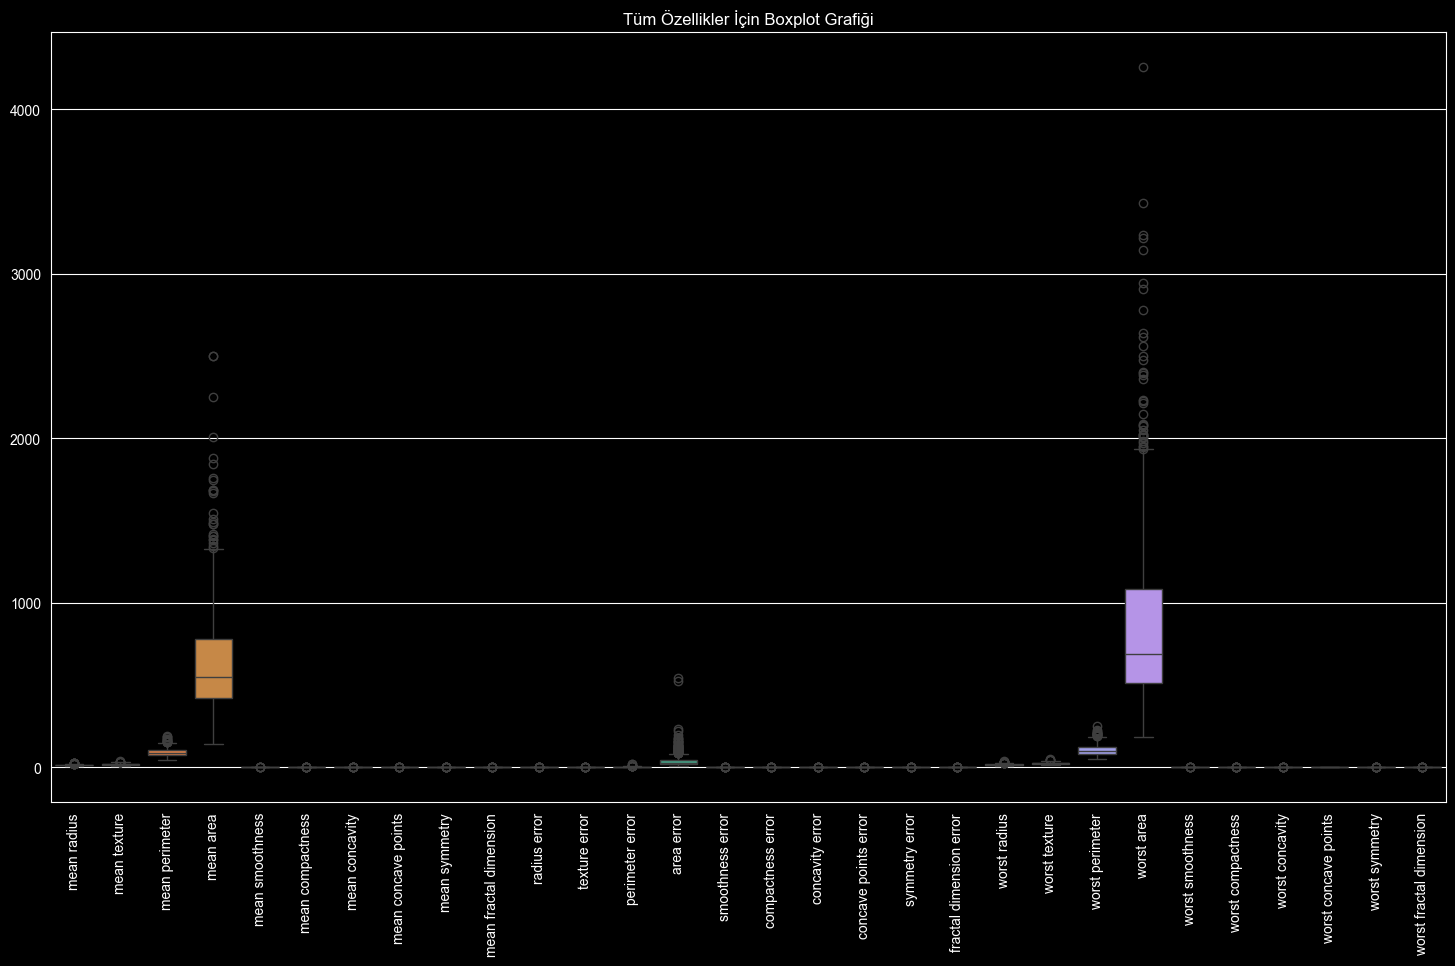

In [39]:
plt.figure(figsize=(18, 10))
sns.boxplot(data=X)
plt.xticks(rotation=90)
plt.title('Tüm Özellikler İçin Boxplot Grafiği')
plt.show()

Boxplot grafikleri bazı sütunlarda aykırı değer olabilecek gözlemler bulunduğunu göstermektedir. Özellikle
kutu grafiğinin dışında kalan noktalar dikkat çekmektedir. Bu değerler bazı modelleri etkileyebileceği için
sonraki adımlarda ölçeklendirme ve model seçimi önemli olacaktır.


## 2.4 Bölümün Toplu Çalışan Kodu

In [40]:
missing_values = X.isnull().sum()
print(missing_values)

print('Toplam eksik değer sayısı:', X.isnull().sum().sum())

print(X.dtypes)
print(X.dtypes.value_counts())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64
Toplam eksik değer sayısı: 0
mean radius                float64
mean texture               float64
mean perimeter    

## 2. Bölüm Sonu Yorumu

Veri setinde yapılan kalite kontrolleri sonucunda hiçbir sütunda eksik gözlem bulunmadığı görülmüştür. Ayrıca
tüm değişkenlerin sayısal ve `float64` tipinde olduğu belirlenmiştir. Boxplot incelemesi ise bazı
değişkenlerde aykırı değer olabilecek gözlemler bulunduğunu göstermiştir. Bu durum, veri setinin genel olarak
analize uygun olduğunu; ancak ölçeklendirme ve modelleme aşamalarında aykırı değer etkisinin dikkate alınması
gerektiğini göstermektedir.


# 3. Keşifsel Veri Analizi (EDA)

Bu bölümde, modeli kurmadan önce veriyi daha iyi tanımak için temel istatistiklere ve değişkenler arası ilişkilere bakıyorum.

## 3.1 Temel İstatistikler

Önce sayısal değişkenlerin özetini (ortalama, standart sapma, çeyreklikler vb.) çıkarıyorum.

In [41]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

# df, 1. bölümde oluşturulmuştu (X + target).
# Burada EDA için hızlı bir özet tablo alıyorum.
istatistik_ozet = df.drop(columns=['target']).describe().T
istatistik_ozet.head()


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.7800,28.1100
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.8000,39.2800
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.1000,188.5000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.7000,2501.0000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634


In [42]:
# İstersem tüm tabloyu da görüntüleyebilirim:
istatistik_ozet


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [43]:
# Target'a göre bazı özelliklerin ortalaması nasıl değişiyor?
df.groupby('target').mean(numeric_only=True).iloc[:, :8]  # ilk 8 özelliği örnek olarak gösteriyorum


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points
target,,,,,,,,
0,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990
1,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717


## 3.2 Korelasyon Matrisi ve Heatmap

Korelasyon, iki değişkenin birlikte nasıl değiştiğini gösterir. Çok yüksek korelasyonlar bazı modellerde
(özellikle doğrusal) benzer bilgiyi tekrar taşıyor olabilir.


Kaydedildi: /Users/barisrefikaykent/PyCharmMiscProject/figures/03_korelasyon_heatmap.svg


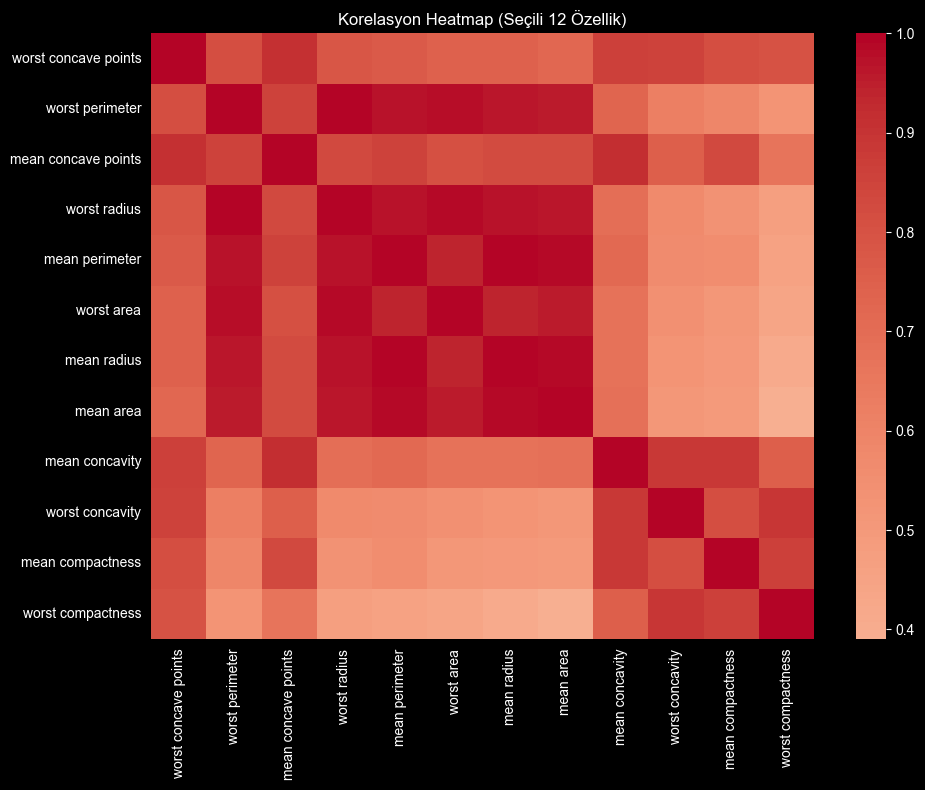

In [44]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Tüm özellikler için korelasyon matrisi
korelasyon = X.corr()

# Heatmap çok kalabalık olmasın diye, hedef değişkenle en ilişkili ilk 12 özelliği seçiyorum
hedef_korelasyon = X.corrwith(y).abs().sort_values(ascending=False)
secili_ozellikler = hedef_korelasyon.index[:12]
korelasyon_secili = korelasyon.loc[secili_ozellikler, secili_ozellikler]

plt.figure(figsize=(10, 8))
sns.heatmap(korelasyon_secili, cmap='coolwarm', center=0, annot=False)
plt.title('Korelasyon Heatmap (Seçili 12 Özellik)')
plt.tight_layout()

def repo_kokunu_bul() -> Path:
    # Önce Git reposunun kökünü (.git üzerinden) bulmaya çalışıyorum
    cwd = Path.cwd()
    for p in [cwd, *cwd.parents]:
        if (p / '.git').exists():
            return p
    # Colab vb. ortamlarda .git olmayabilir; o zaman mevcut dizini kök kabul ediyorum
    return cwd

repo_kok = repo_kokunu_bul()
figures_dir = repo_kok / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
cikis_dosyasi = figures_dir / '03_korelasyon_heatmap.svg'

plt.savefig(cikis_dosyasi)
print('Kaydedildi:', cikis_dosyasi.resolve())
plt.show()


In [45]:
# En yüksek mutlak korelasyona sahip ilk 3 değişken çifti
korelasyon_abs = korelasyon.abs()
ust_ucgen = korelasyon_abs.where(np.triu(np.ones(korelasyon_abs.shape), k=1).astype(bool))
en_yuksek = (
    ust_ucgen.stack()
    .sort_values(ascending=False)
    .head(3)
)
en_yuksek


mean radius   mean perimeter     0.997855
worst radius  worst perimeter    0.993708
mean radius   mean area          0.987357
dtype: float64

## 3. Bölüm Sonu Yorumu

Bu adımda verinin genel dağılımını ve değişkenlerin birbiriyle ilişkisini gördüm. Korelasyon matrisi özellikle
çok benzer bilgi taşıyan özellikleri fark etmeme yardımcı oldu.


# 4. Veri Ölçeklendirme (Scaling)

Ne yapıyoruz?
- Özelliklerin (kolonların) ölçeklerini inceliyoruz ve neden ölçeklendirme gerektiğini gerekçelendiriyoruz.
- Ölçeklendirmeyi **split işleminden sonra** (5. adımda) uygulayacağız. Burada amaç, yöntemi doğru yerde kullanmak ve veri sızıntısını önlemektir.


In [46]:
# Ölçekler hakkında hızlı bir fikir edinmek için bazı özet istatistiklere bakıyorum
olcek_ozeti = X.describe().loc[['mean', 'std', 'min', 'max']].T
display(olcek_ozeti.head(10))

print('Örnek olarak ilk 10 kolon gösterildi. Tüm kolonların ölçeklerini görmek isterseniz `olcek_ozeti` değişkenini görüntüleyebilirsiniz.')


,mean,std,min,max
mean radius,14.127292,3.524049,6.98100,28.11000
mean texture,19.289649,4.301036,9.71000,39.28000
mean perimeter,91.969033,24.298981,43.79000,188.50000
mean area,654.889104,351.914129,143.50000,2501.00000
mean smoothness,0.096360,0.014064,0.05263,0.16340
mean compactness,0.104341,0.052813,0.01938,0.34540
mean concavity,0.088799,0.079720,0.00000,0.42680
mean concave points,0.048919,0.038803,0.00000,0.20120
mean symmetry,0.181162,0.027414,0.10600,0.30400
mean fractal dimension,0.062798,0.007060,0.04996,0.09744


Örnek olarak ilk 10 kolon gösterildi. Tüm kolonların ölçeklerini görmek isterseniz `olcek_ozeti` değişkenini görüntüleyebilirsiniz.


**Çıktı Yorumu (Akademik):**
Özet istatistikler, bazı özelliklerin değer aralıklarının diğerlerine göre çok daha büyük olabildiğini göstermektedir.
Bu durum özellikle doğrusal modellerde ve PCA gibi varyans-temelli yöntemlerde, büyük ölçekli değişkenlerin modele gereğinden
fazla ağırlık vermesine neden olabilir. Bu nedenle StandardScaler gibi bir ölçeklendirme yaklaşımı kullanılacaktır.


In [47]:
from sklearn.preprocessing import StandardScaler

# Not: scaler'ı burada tanımlıyorum; fit/transform işlemini veri sızıntısını önlemek için 5. adımda split sonrasında yapacağım.
scaler = StandardScaler()
print('StandardScaler hazır. (fit işlemi split sonrası uygulanacak)')


StandardScaler hazır. (fit işlemi split sonrası uygulanacak)


**Çıktı Yorumu (Akademik):**
Ölçeklendirme işleminin doğru uygulanabilmesi için, dönüşüm parametrelerinin yalnızca eğitim verisinden öğrenilmesi gerekir.
Bu yaklaşım, validation ve test setlerinin eğitim sürecine dolaylı olarak dahil olmasını (data leakage) engeller.


# 5. Veri Setinin Bölünmesi

Ne yapıyoruz?
- Veri setini **train / validation / test** olarak 70/10/20 oranında ayırıyoruz.
- Sınıf oranlarını korumak için **stratified split** kullanıyoruz.
- Ardından (4. adımda tanımladığımız) ölçeklendirmeyi sadece `train` üzerinde öğrenip, `validation` ve `test` setlerine uyguluyoruz.


In [48]:
from sklearn.model_selection import train_test_split

# 1) Önce test setini ayır (20%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 2) Kalan 80% içinden validation ve test'i eşit böl (10% + 10%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print('Eğitim (train) boyutu:', X_train.shape, 'Hedef:', y_train.shape)
print('Doğrulama (validation) boyutu:', X_val.shape, 'Hedef:', y_val.shape)
print('Test boyutu:', X_test.shape, 'Hedef:', y_test.shape)


Eğitim (train) boyutu: (455, 30) Hedef: (455,)
Doğrulama (validation) boyutu: (57, 30) Hedef: (57,)
Test boyutu: (57, 30) Hedef: (57,)


In [49]:
print('Train sınıf oranları:')
print(y_train.value_counts(normalize=True))

print('Validation sınıf oranları:')
print(y_val.value_counts(normalize=True))

print('Test sınıf oranları:')
print(y_test.value_counts(normalize=True))


Train sınıf oranları:
target
1    0.626374
0    0.373626
Name: proportion, dtype: float64
Validation sınıf oranları:
target
1    0.631579
0    0.368421
Name: proportion, dtype: float64
Test sınıf oranları:
target
1    0.631579
0    0.368421
Name: proportion, dtype: float64


**Çıktı Yorumu (Akademik):**
Stratified bölme sayesinde, train/validation/test alt kümelerinde sınıf oranlarının birbirine yakın kaldığı görülür.
Bu durum, performans karşılaştırmalarının daha adil yapılmasına katkı sağlar.


In [50]:
import pandas as pd

# Ölçeklendirme: fit sadece train, transform val/test
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Kolon isimlerini kaybetmemek için DataFrame'e çeviriyorum
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_val_scaled   = pd.DataFrame(X_val_scaled,   columns=X.columns, index=X_val.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns, index=X_test.index)

print('Ölçeklendirilmiş train boyutu:', X_train_scaled.shape)
display(X_train_scaled.head())


Ölçeklendirilmiş train boyutu: (455, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
546,-1.072001,-0.658425,-1.088080,-0.939274,-0.135940,-1.008718,-0.968359,-1.102032,0.281062,-0.113231,-0.704861,-0.440938,-0.743949,-0.629805,0.000748,-0.991573,-0.693760,-0.983284,-0.591579,-0.428972,-1.034094,-0.623497,-1.070773,-0.876534,-0.169982,-1.038836,-1.078995,-1.350527,-0.352658,-0.541380
432,1.748743,0.066502,1.751157,1.745559,1.274468,0.842288,1.519852,1.994664,-0.293045,-0.320180,0.127567,-0.381383,0.094075,0.317524,0.639656,0.087389,0.708451,1.182150,0.426212,0.074797,1.228342,-0.092833,1.187467,1.104386,1.517001,0.249655,1.178594,1.549916,0.191078,-0.173739
174,-0.974734,-0.931124,-0.997709,-0.867589,-0.613515,-1.138154,-1.092292,-1.243358,0.434395,-0.429247,-0.254445,1.237130,-0.338634,-0.413827,0.520240,-0.833114,-1.006736,-1.857894,1.356046,-1.006560,-0.973231,-1.036772,-1.008044,-0.834168,-1.097823,-1.167260,-1.282241,-1.707442,-0.307734,-1.213033
221,-0.145103,-1.215186,-0.123013,-0.253192,0.664482,0.286762,-0.129729,-0.098605,0.555635,0.029395,-0.531049,-1.262281,-0.411682,-0.436600,-0.393580,-0.129997,-0.219965,-0.527278,-0.269450,-0.316623,-0.251266,-1.369643,-0.166633,-0.330292,0.234006,0.096874,-0.087521,-0.344838,0.242198,-0.118266
289,-0.771617,-0.081211,-0.803700,-0.732927,-0.672282,-1.006099,-0.798502,-0.684484,0.737495,-0.457213,-0.498529,1.322961,-0.440597,-0.521457,-0.174225,-0.628196,-0.581187,-0.278344,1.528534,-0.313022,-0.801135,0.079230,-0.824381,-0.741830,-0.911367,-0.984612,-0.933190,-0.777604,0.555118,-0.761639


**Çıktı Yorumu (Akademik):**
Ölçeklendirme sonrası veri boyutları korunur ve dönüşüm parametreleri yalnızca eğitim verisinden öğrenildiği için veri sızıntısı
riski azaltılmış olur. Bu ölçeklendirilmiş veri, PCA/LDA ve bazı modeller için daha uygun bir girdi sağlar.


# 6. Özellik Seçimi ve Boyut İndirgeme

Ne yapıyoruz?
- PCA ile etiket kullanmadan (unsupervised) boyut indirgeme yapıyoruz.
- LDA ile etiket bilgisi kullanarak (supervised) sınıfları ayıran doğrusal ekseni elde ediyoruz.
- Her iki dönüşümü de yalnızca `train` üzerinde öğrenip, `validation` ve `test` setlerine uyguluyoruz.


In [51]:
from pathlib import Path

def repo_kokunu_bul() -> Path:
    cwd = Path.cwd()
    for p in [cwd, *cwd.parents]:
        if (p / '.git').exists():
            return p
    return cwd

repo_kok = repo_kokunu_bul()
figures_dir = repo_kok / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
print('Şekiller klasörü:', figures_dir.resolve())


Şekiller klasörü: /Users/barisrefikaykent/PyCharmMiscProject/figures


## 6.1 PCA (Boyut İndirgeme)

Ne yapıyoruz?
- PCA’yı `train` setinde öğreniyoruz.
- Ödev kuralına göre, explained variance oranı ortalamasından büyük olan bileşenleri seçiyoruz.


In [52]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca_tam = PCA(random_state=42)
pca_tam.fit(X_train_scaled)

oranlar = pca_tam.explained_variance_ratio_
esik = oranlar.mean()
secili_bilesen_sayisi = int((oranlar > esik).sum())

print('Toplam bileşen sayısı:', len(oranlar))
print('Ortalama explained variance oranı:', esik)
print('Seçilen bileşen sayısı:', secili_bilesen_sayisi)


Toplam bileşen sayısı: 30
Ortalama explained variance oranı: 0.03333333333333333
Seçilen bileşen sayısı: 6


Kaydedildi: /Users/barisrefikaykent/PyCharmMiscProject/figures/06_pca_explained_variance.svg


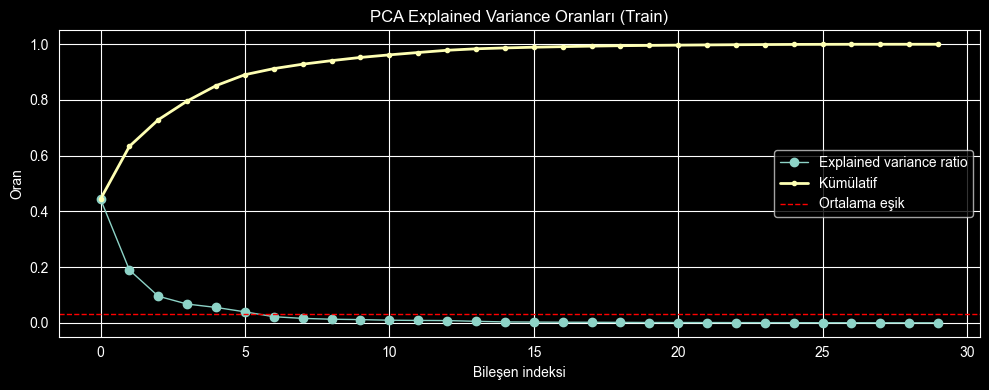

In [53]:
kumulatif = np.cumsum(oranlar)

plt.figure(figsize=(10, 4))
plt.plot(oranlar, marker='o', linewidth=1, label='Explained variance ratio')
plt.plot(kumulatif, marker='.', linewidth=2, label='Kümülatif')
plt.axhline(esik, color='red', linestyle='--', linewidth=1, label='Ortalama eşik')
plt.title('PCA Explained Variance Oranları (Train)')
plt.xlabel('Bileşen indeksi')
plt.ylabel('Oran')
plt.legend()
plt.tight_layout()

cikis = figures_dir / '06_pca_explained_variance.svg'
plt.savefig(cikis)
print('Kaydedildi:', cikis.resolve())
plt.show()


**Çıktı Yorumu (Akademik):**
Seçilen bileşen sayısı, ödevde belirtilen kurala göre varyansı ortalamanın üzerinde açıklayan bileşenlerin sayısıdır.
Kümülatif varyans eğrisi ise seçilen bileşenlerin toplam bilginin ne kadarını taşıdığını gösterir.


In [54]:
pca = PCA(n_components=secili_bilesen_sayisi, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca   = pca.transform(X_val_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print('Train PCA boyutu:', X_train_pca.shape)
print('Validation PCA boyutu:', X_val_pca.shape)
print('Test PCA boyutu:', X_test_pca.shape)


Train PCA boyutu: (455, 6)
Validation PCA boyutu: (57, 6)
Test PCA boyutu: (57, 6)


Kaydedildi: /Users/barisrefikaykent/PyCharmMiscProject/figures/06_pca_scatter_train.svg


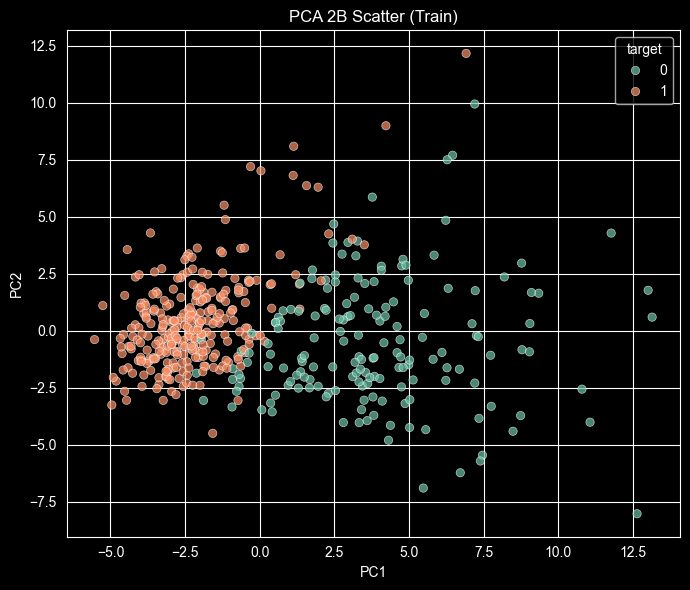

In [55]:
import seaborn as sns

pca_viz = PCA(n_components=2, random_state=42)
X_train_2d = pca_viz.fit_transform(X_train_scaled)

pca_df = pd.DataFrame(X_train_2d, columns=['PC1', 'PC2'], index=y_train.index)
pca_df['target'] = y_train.values

plt.figure(figsize=(7, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='target', palette='Set2', alpha=0.7)
plt.title('PCA 2B Scatter (Train)')
plt.tight_layout()

cikis = figures_dir / '06_pca_scatter_train.svg'
plt.savefig(cikis)
print('Kaydedildi:', cikis.resolve())
plt.show()


## 6.2 LDA (Sınıf Ayırıcı Boyut İndirgeme)

Ne yapıyoruz?
- LDA etiketi (`y`) kullanır ve sınıfları ayıran doğrusal ekseni bulur.
- İki sınıflı problemde maksimum bileşen sayısı `n_classes - 1 = 1` olduğu için 1 bileşenle ilerliyoruz.


In [56]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=1)

X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_val_lda   = lda.transform(X_val_scaled)
X_test_lda  = lda.transform(X_test_scaled)

print('Train LDA boyutu:', X_train_lda.shape)
print('Validation LDA boyutu:', X_val_lda.shape)
print('Test LDA boyutu:', X_test_lda.shape)


Train LDA boyutu: (455, 1)
Validation LDA boyutu: (57, 1)
Test LDA boyutu: (57, 1)


Kaydedildi: /Users/barisrefikaykent/PyCharmMiscProject/figures/06_lda_hist_train.svg


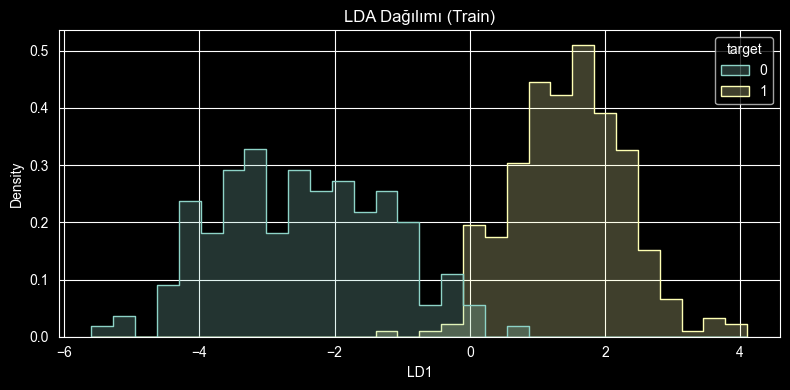

In [57]:
lda_df = pd.DataFrame({'LD1': X_train_lda.ravel(), 'target': y_train.values})

plt.figure(figsize=(8, 4))
sns.histplot(data=lda_df, x='LD1', hue='target', stat='density', common_norm=False, bins=30, element='step')
plt.title('LDA Dağılımı (Train)')
plt.tight_layout()

cikis = figures_dir / '06_lda_hist_train.svg'
plt.savefig(cikis)
print('Kaydedildi:', cikis.resolve())
plt.show()


## 6. Bölüm Sonu Yorumu

Bu adımda PCA ve LDA ile iki farklı boyut indirgeme temsili elde edildi. Bir sonraki aşamada ham (ölçeklendirilmiş), PCA ve LDA
temsilini kullanarak modelleri kuracak ve validation performanslarını karşılaştıracağız.


# 7. Makine Öğrenmesi Modellerinin Kurulması

Ne yapıyoruz?
- Ödevde istenen 5 farklı modeli tanımlıyoruz: Logistic Regression, Decision Tree, Random Forest, XGBoost, GaussianNB.
- Bu modelleri 3 farklı temsil üzerinde (ham/ PCA/ LDA) aynı şekilde eğitmeye hazır bir yapı kuruyoruz.


In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

try:
    from xgboost import XGBClassifier
    xgb_var = True
except Exception as e:
    xgb_var = False
    print('Uyarı: xgboost yüklenemedi. requirements.txt kurulumunu kontrol edin. Hata:', e)

modeller = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42),
    'GaussianNB': GaussianNB(),
}

if xgb_var:
    modeller['XGBoost'] = XGBClassifier(
        n_estimators=400, max_depth=4, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9,
        reg_lambda=1.0, random_state=42, eval_metric='logloss'
    )

print('Tanımlanan modeller:', list(modeller.keys()))


Uyarı: xgboost yüklenemedi. requirements.txt kurulumunu kontrol edin. Hata: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/barisrefikaykent/PyCharmMiscProject/.venv/lib/python3.14/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <1A0D8152-BF46-3BE0-B651-EE965C187777> /Users/barisrefikaykent/PyCharmMiscProject/.venv/lib/python3.14/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.d

**Çıktı Yorumu (Akademik):**
Bu aşamada modeller sadece tanımlanmıştır. Eğitim ve performans ölçümü bir sonraki adımda (validation değerlendirmesi) yapılacaktır.


# 8. Validation Performanslarının Ölçülmesi

Ne yapıyoruz?
- Her model için validation seti üzerinde metrikleri (Accuracy, Precision, Recall, F1-score, ROC-AUC) hesaplıyoruz.
- Ham (ölçeklendirilmiş), PCA ve LDA temsilleri için sonuçları tek tabloda karşılaştırıyoruz.
- Eğer sonuçlar olağanüstü iyi (ör. 1.0) görünüyorsa bunu not edip, çapraz doğrulama gibi ek kontrollerle sorguluyoruz.


In [59]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def metrikleri_hesapla(y_true, y_pred, y_prob):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_prob),
    }

veri_temsilleri = {
    'Ham (Ölçeklendirilmiş)': (X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test),
    'PCA': (X_train_pca, y_train, X_val_pca, y_val, X_test_pca, y_test),
    'LDA': (X_train_lda, y_train, X_val_lda, y_val, X_test_lda, y_test),
}

sonuclar = []

for temsil_adi, (Xtr, ytr, Xva, yva, Xte, yte) in veri_temsilleri.items():
    for model_adi, model in modeller.items():
        model.fit(Xtr, ytr)
        y_pred = model.predict(Xva)
        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(Xva)[:, 1]
        else:
            # Bu ödevde kullandığımız modellerde predict_proba var; yine de güvenli olsun
            y_prob = y_pred
        m = metrikleri_hesapla(yva, y_pred, y_prob)
        m.update({'temsil': temsil_adi, 'model': model_adi})
        sonuclar.append(m)

sonuclar_df = pd.DataFrame(sonuclar)
sonuclar_df = sonuclar_df.sort_values(by=['roc_auc', 'f1'], ascending=False)
display(sonuclar_df.head(15))

print('Toplam model sayısı:', len(sonuclar_df))


,accuracy,precision,recall,f1,roc_auc,temsil,model
0,1.000000,1.000000,1.000000,1.000000,1.000000,Ham (Ölçeklendirilmiş),Logistic Regression
4,1.000000,1.000000,1.000000,1.000000,1.000000,PCA,Logistic Regression
2,0.982456,0.972973,1.000000,0.986301,0.998677,Ham (Ölçeklendirilmiş),Random Forest
7,0.982456,1.000000,0.972222,0.985915,0.997354,PCA,GaussianNB
6,0.964912,0.972222,0.972222,0.972222,0.996032,PCA,Random Forest
8,0.982456,0.972973,1.000000,0.986301,0.994709,LDA,Logistic Regression
11,0.964912,0.947368,1.000000,0.972973,0.994709,LDA,GaussianNB
3,0.964912,0.972222,0.972222,0.972222,0.994709,Ham (Ölçeklendirilmiş),GaussianNB
10,0.947368,0.971429,0.944444,0.957746,0.994709,LDA,Random Forest
5,0.947368,0.971429,0.944444,0.957746,0.948413,PCA,Decision Tree


Toplam model sayısı: 12


In [61]:
en_iyi_satir = sonuclar_df.iloc[0]
print('''Validation'a göre en iyi seçim:''')
print('Temsil:', en_iyi_satir['temsil'])
print('Model :', en_iyi_satir['model'])
print('ROC-AUC:', en_iyi_satir['roc_auc'])
print('F1    :', en_iyi_satir['f1'])


Validation'a göre en iyi seçim:
Temsil: Ham (Ölçeklendirilmiş)
Model : Logistic Regression
ROC-AUC: 1.0
F1    : 1.0


**Çıktı Yorumu (Akademik):**
Validation sonuçları, farklı temsil ve modellerin karşılaştırmalı performansını gösterir. Eğer bazı kombinasyonlarda ROC-AUC veya
Accuracy değerleri 1.0’a çok yakın ya da tam 1.0 ise, bu durum veri setinin ayrılabilirliğinden kaynaklanabileceği gibi validation
setinin görece küçük olması nedeniyle de görülebilir. Bu nedenle, en iyi modelin test seti üzerindeki performansı ayrıca raporlanmalıdır.


# 9. En İyi Modelin Test Üzerinde Değerlendirilmesi

Ne yapıyoruz?
- Validation sonuçlarına göre seçilen en iyi model/temsil kombinasyonunu alıyoruz.
- Modeli eğitim + doğrulama verisi üzerinde yeniden eğitip, sadece test seti üzerinde değerlendiriyoruz.
- Confusion matrix ve ROC curve gibi grafiklerle performansı raporluyoruz.


Test ROC-AUC: 0.9841269841269842
Test Accuracy: 0.9649122807017544
Test F1-score: 0.9722222222222222


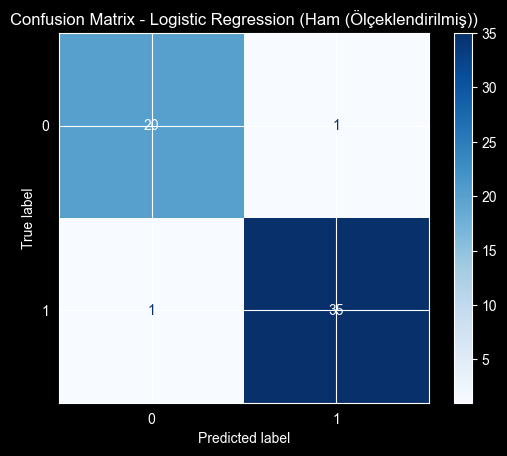

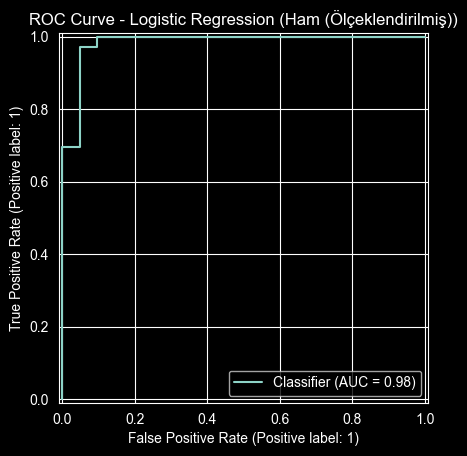

In [63]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score,
    accuracy_score,
    f1_score
)
import matplotlib.pyplot as plt
import pandas as pd

def temsil_verisini_getir(temsil_adi):
    Xtr, ytr, Xva, yva, Xte, yte = veri_temsilleri[temsil_adi]
    return Xtr, ytr, Xva, yva, Xte, yte

secili_temsil = en_iyi_satir['temsil']
secili_model_adi = en_iyi_satir['model']

Xtr, ytr, Xva, yva, Xte, yte = temsil_verisini_getir(secili_temsil)

# Train + Validation setlerini birleştirerek final modeli yeniden eğit
# DataFrame yapısını korumak için pd.concat kullanıyoruz
X_trainval = pd.concat([Xtr, Xva], axis=0)
y_trainval = pd.concat([ytr, yva], axis=0)

# Final modeli seç ve eğit
model_final = modeller[secili_model_adi]
model_final.fit(X_trainval, y_trainval)

# Test tahminleri
y_test_pred = model_final.predict(Xte)

# Olasılık tahmini varsa ROC-AUC için kullan
if hasattr(model_final, 'predict_proba'):
    y_test_prob = model_final.predict_proba(Xte)[:, 1]
else:
    y_test_prob = y_test_pred

# Test metrikleri
print('Test ROC-AUC:', roc_auc_score(yte, y_test_prob))
print('Test Accuracy:', accuracy_score(yte, y_test_pred))
print('Test F1-score:', f1_score(yte, y_test_pred))

# Confusion Matrix
cm = confusion_matrix(yte, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix - {secili_model_adi} ({secili_temsil})')
plt.show()

# ROC Curve
RocCurveDisplay.from_predictions(yte, y_test_prob)
plt.title(f'ROC Curve - {secili_model_adi} ({secili_temsil})')
plt.show()


Kaydedildi: /Users/barisrefikaykent/PyCharmMiscProject/figures/09_confusion_matrix_test.svg


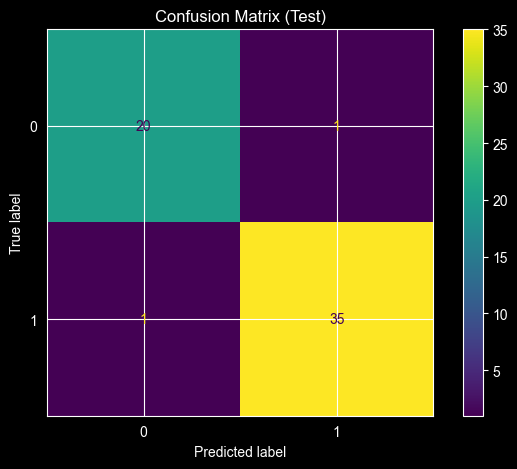

In [64]:
# Confusion Matrix
cm = confusion_matrix(yte, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format='d')
plt.title('Confusion Matrix (Test)')
plt.tight_layout()
cikis = figures_dir / '09_confusion_matrix_test.svg'
plt.savefig(cikis)
print('Kaydedildi:', cikis.resolve())
plt.show()


Kaydedildi: /Users/barisrefikaykent/PyCharmMiscProject/figures/09_roc_curve_test.svg


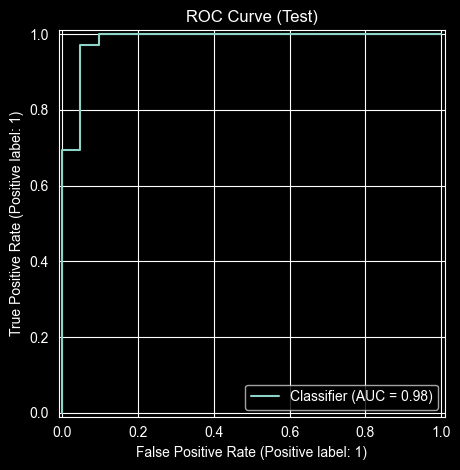

In [65]:
# ROC Curve
roc_disp = RocCurveDisplay.from_predictions(yte, y_test_prob)
plt.title('ROC Curve (Test)')
plt.tight_layout()
cikis = figures_dir / '09_roc_curve_test.svg'
plt.savefig(cikis)
print('Kaydedildi:', cikis.resolve())
plt.show()


**Çıktı Yorumu (Akademik):**
Test seti, modelin genellenebilirliğini değerlendirmek için ayrılmıştır ve eğitim/validasyon sürecine dahil edilmemelidir.
Confusion matrix, yanlış sınıflandırma sayısını açıkça gösterirken; ROC eğrisi eşik-bağımsız performansı görselleştirir.
Eğer test performansı da olağanüstü yüksek çıkarsa, veri setinin ayrılabilirliği yanında veri sızıntısı olasılığına karşı
kullanılan veri akışı (split → fit scaler/PCA/LDA yalnızca train) tekrar kontrol edilmelidir.


# 10. XAI – SHAP Açıklanabilirlik Analizi (Zorunlu)

Ne yapıyoruz?
- En iyi modelin kararlarını hangi özelliklerin ne yönde etkilediğini SHAP ile açıklıyoruz.
- En azından bir `summary_plot` ve bir önem sıralaması grafiği üreteceğiz.

Not: SHAP analizi model türüne göre farklı açıklayıcılar (TreeExplainer/LinearExplainer) kullanır.


In [69]:
import numpy as np

try:
    import shap
    shap_var = True
except Exception as e:
    shap_var = False
    print('Uyarı: shap yüklenemedi. requirements.txt kurulumunu kontrol edin. Hata:', e)

print('SHAP hazır mı?:', shap_var)


SHAP hazır mı?: True


Kaydedildi: /Users/barisrefikaykent/PyCharmMiscProject/figures/10_shap_summary.svg


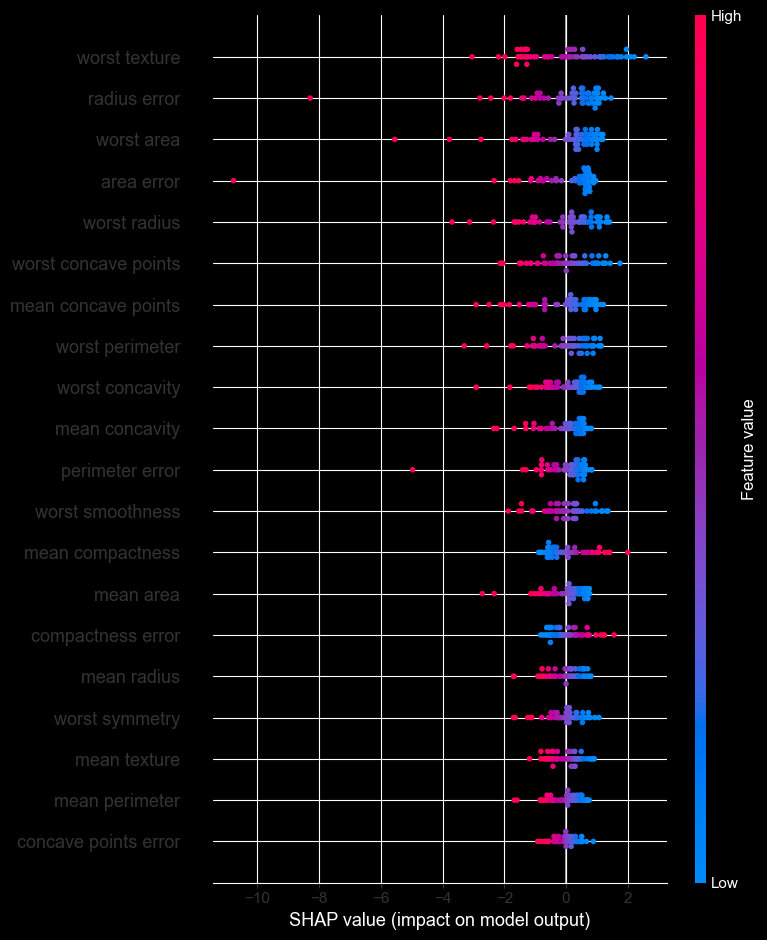

Kaydedildi: /Users/barisrefikaykent/PyCharmMiscProject/figures/10_shap_bar.svg


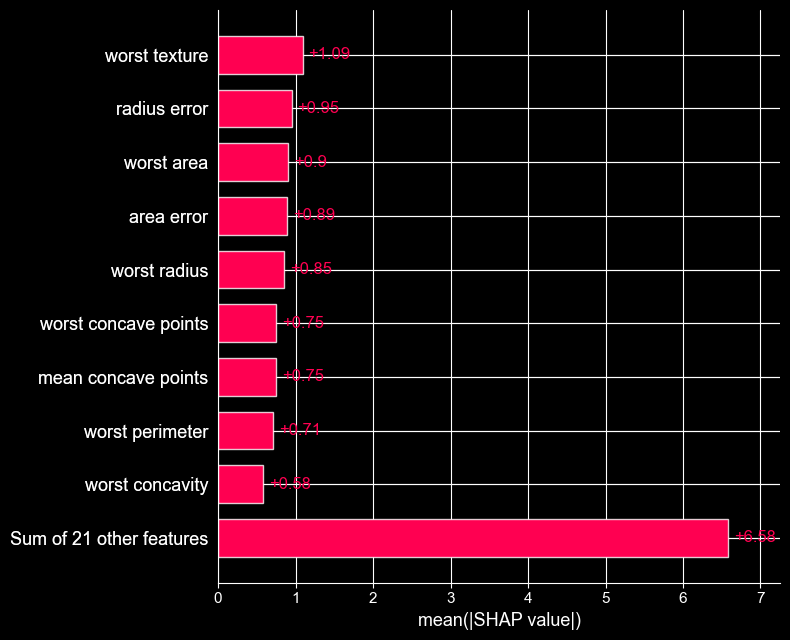

In [72]:
# SHAP analizi (uygun model türlerinde)
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# SHAP analizi
if not shap_var:
    print('SHAP kurulumu olmadığı için bu adım atlandı.')
else:
    # Temsile göre test verisi ve özellik isimleri
    if secili_temsil == 'Ham (Ölçeklendirilmiş)':
        X_test_for_shap = Xte.copy()
        if not isinstance(X_test_for_shap, pd.DataFrame):
            X_test_for_shap = pd.DataFrame(X_test_for_shap, columns=X.columns)
        feature_names = list(X_test_for_shap.columns)

    elif secili_temsil == 'PCA':
        X_test_for_shap = pd.DataFrame(
            Xte,
            columns=[f'PC{i+1}' for i in range(Xte.shape[1])]
        )
        feature_names = list(X_test_for_shap.columns)

    else:  # LDA
        X_test_for_shap = pd.DataFrame(
            Xte,
            columns=[f'LD{i+1}' for i in range(Xte.shape[1])]
        )
        feature_names = list(X_test_for_shap.columns)

    # Örneklem al
    X_sample = X_test_for_shap.sample(n=min(200, len(X_test_for_shap)), random_state=42)

    model_for_shap = model_final

    try:
        # Genel ve güvenli kullanım
        explainer = shap.Explainer(model_for_shap, X_sample)
        shap_values = explainer(X_sample)

        # Summary plot
        shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=False)
        cikis = figures_dir / '10_shap_summary.svg'
        plt.tight_layout()
        plt.savefig(cikis)
        print('Kaydedildi:', cikis.resolve())
        plt.show()

        # Bar plot
        shap.plots.bar(shap_values, show=False)
        cikis = figures_dir / '10_shap_bar.svg'
        plt.tight_layout()
        plt.savefig(cikis)
        print('Kaydedildi:', cikis.resolve())
        plt.show()

    except Exception as e:
        print('SHAP bu model/temsil için çalışmadı. Hata:', e)


**Çıktı Yorumu (Akademik):**
SHAP grafikleri, modelin hangi özellikleri daha etkili kullandığını ve bu özelliklerin tahminleri hangi yönde etkilediğini gösterir.
Özellikle `summary_plot`, örnek bazında etki dağılımını verirken; bar grafiği ortalama mutlak SHAP değerleri üzerinden genel önem sıralaması
sunar. Bu yorumlar, modelin sadece performans açısından değil, karar mekanizması açısından da raporlanmasına imkan tanır.
